## 🚨 Handling Outliers

Outliers are data points that deviate significantly from other observations in the dataset. They can distort statistical analysis and model performance.

---

### 🔍 Step 1: Detect Outliers

Common methods:

- **Box Plot**:
  - Visual method.
  - Points outside whiskers (1.5×IQR) are potential outliers.
- **Z-score**:
  - Outliers have |Z| > 3 (standard deviations from mean).
- **IQR (Interquartile Range)**:
  - Lower Bound = Q1 - 1.5 × IQR  
  - Upper Bound = Q3 + 1.5 × IQR  
  - Values outside this range are outliers.

In [1]:
# Example: Using IQR
import numpy as np
import pandas as pd

data = pd.DataFrame({'value': [10, 12, 11, 13, 10, 500]})  # 500 is an outlier
Q1 = data['value'].quantile(0.25)
Q3 = data['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['value'] < lower_bound) | (data['value'] > upper_bound)]
print("Outliers:\n", outliers)


Outliers:
    value
5    500


<Axes: >

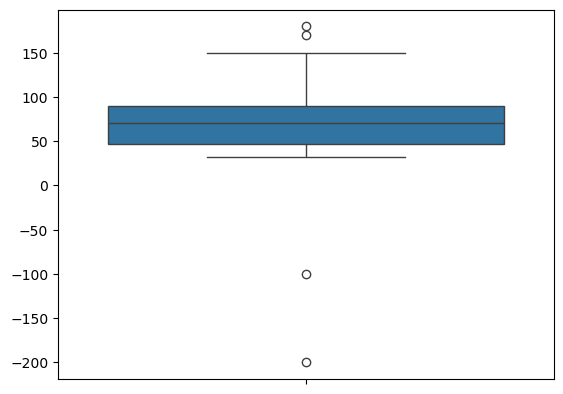

In [3]:
# using box plot
import seaborn as sns
lst_marks=[-100,-200,45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74,150,170,180]
sns.boxplot(lst_marks)

In [6]:
# using z score
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Simulate a larger dataset
values = [10, 12, 11, 13, 10, 12, 11, 13, 500]  # Now 500 is more extreme
data = pd.DataFrame({'value': values})

# Calculate Z-scores
data['z_score'] = zscore(data['value'])

# Detect outliers (|Z| > 3) //f you want to catch milder outliers, change the condition to: 2.5
data['outlier'] = data['z_score'].abs() > 2.5

print(data)


   value   z_score  outlier
0     10 -0.363315    False
1     12 -0.350288    False
2     11 -0.356802    False
3     13 -0.343775    False
4     10 -0.363315    False
5     12 -0.350288    False
6     11 -0.356802    False
7     13 -0.343775    False
8    500  2.828360     True
